In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [104]:
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R

def extract_original_orientation(df):
    """
    Extract the original pitch, yaw, and roll from the vive_data column
    and add them as separate columns to the DataFrame.
    """
    # Extract Vive orientation data
    vive_data = df['vive_data'].apply(lambda v: np.fromstring(v.strip('[]'), sep=' '))
    orientations = np.stack(vive_data.to_list())[:, 3:]  # Extract yaw, pitch, roll
    
    # Add columns for the original orientation
    df[['yaw', 'pitch', 'roll']] = orientations
    return df

def transform_positions_to_robot_frame(df):
    """
    Transforms positional data (x, y, z) from the Vive frame to the robot frame.
    """
    # Extract Vive positions
    vive_data = df['vive_data'].apply(lambda v: np.fromstring(v.strip('[]'), sep=' '))
    positions = np.stack(vive_data.to_list())[:, :3]

    # Fit a plane to the Vive positions
    def fit_plane(points):
        centroid = np.mean(points, axis=0)
        centered_points = points - centroid
        _, _, vh = np.linalg.svd(centered_points)
        normal = vh[-1]
        return normal, centroid

    # Fit the plane and compute the rotation matrix
    normal, centroid = fit_plane(positions)
    target_normal = np.array([0, 0, 1])  # Robot's x-y plane (z-aligned)
    rotation_axis = np.cross(normal, target_normal)
    rotation_angle = np.arccos(np.dot(normal, target_normal) / np.linalg.norm(normal))
    plane_alignment_rotation = R.from_rotvec(rotation_axis * rotation_angle).as_matrix()

    # Apply the rotation to align positions
    aligned_positions = (positions - centroid) @ plane_alignment_rotation.T
    aligned_positions -= aligned_positions[0]  # Map the first position to the origin

    # Update the DataFrame with transformed positions
    df[['x', 'y', 'z']] = aligned_positions

    return df

def transform_vive_to_robot_frame(df):
    """
    Transform both positional and orientation data from the Vive frame to the robot frame.
    """
    df = extract_original_orientation(df)
    df = transform_positions_to_robot_frame(df)
    # df = transform_orientation_with_three_reference_points(df)
    return df

# Example usage
df = pd.read_csv('robot_vive_data_log.csv', delimiter='|', header=0)
df.columns = ['position_id', 'timestamp', 'vive_data', 'last_cmd']

# Apply the transformation
aligned_df = transform_vive_to_robot_frame(df)

# Display the first 6 rows of the original pitch, yaw, and roll
print(aligned_df[['yaw', 'pitch', 'roll']].head(6))


          yaw       pitch       roll
0  177.661983 -128.476225 -91.113422
1  177.427305 -127.922757 -92.233005
2  176.566521 -126.857531 -92.934577
3  179.035732  141.384149 -89.217984
4 -179.878824  142.912673 -89.893554
5  179.286779  143.088089 -88.821444


(-2.0, 2.0)

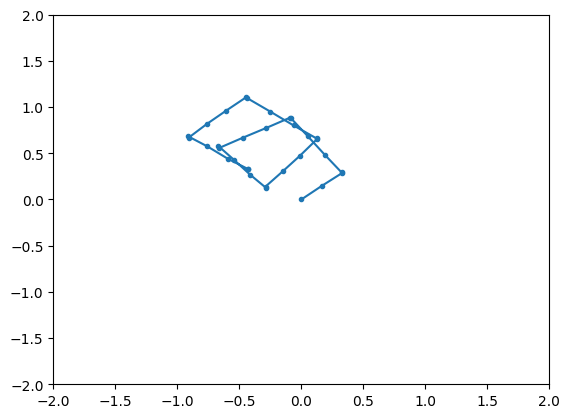

In [107]:
plt.plot(df['x'], df['y'], marker = '.')

plt.xlim(-2,2)
plt.ylim(-2,2)

<Axes: >

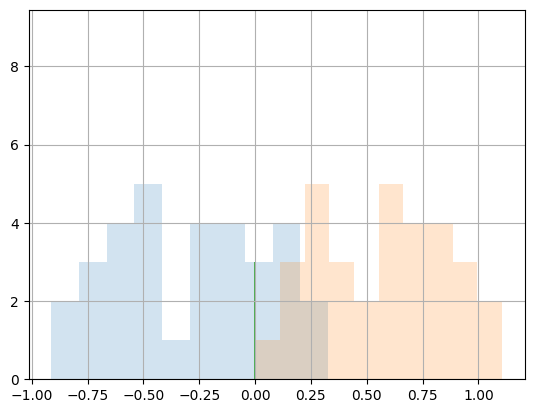

In [63]:

aligned_df['x'].hist(alpha = 0.2)
aligned_df['y'].hist(alpha = 0.2)
aligned_df['z'].hist(alpha = 0.8)


In [109]:
import numpy as np

# Calculate absolute 3D distance traveled
def calculate_distance_3d(df):
    """
    Calculates the 3D distance traveled between consecutive points.
    """
    # Compute differences in x, y, and z between consecutive rows
    df['delta_x'] = df['x'].diff()
    df['delta_y'] = df['y'].diff()
    df['delta_z'] = df['z'].diff()
    
    # Compute the Euclidean distance in 3D
    df['distance_traveled'] = np.sqrt(df['delta_x']**2 + df['delta_y']**2 + df['delta_z']**2)
    
    # Replace NaN for the first row with 0, since there's no previous point to calculate distance
    df['distance_traveled'].fillna(0, inplace=True)
    
    # Drop intermediate columns if not needed
    df.drop(columns=['delta_x', 'delta_y', 'delta_z'], inplace=True)
    
    return df

# Apply the function to your DataFrame
aligned_df = calculate_distance_3d(aligned_df)

aligned_df.head()


C:\Users\15247851\AppData\Local\Temp\ipykernel_4144\2860436413.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['distance_traveled'].fillna(0, inplace=True)


,position_id,timestamp,vive_data,last_cmd,yaw,pitch,roll,x,y,z,distance_traveled
0,0,1.732839e+09,[ 0.26309819 -1.09524618 -1.30876942 17...,MOVE:2000,177.661983,-128.476225,-91.113422,0.000000,0.000000,0.000000,0.000000
1,0,1.732839e+09,[ 0.42968679 -1.09511243 -1.45375959 17...,MOVE:2000,177.427305,-127.922757,-92.233005,0.164759,0.147035,-0.003036,0.220848
2,0,1.732839e+09,[ 0.59399218 -1.09135685 -1.590056 17...,MOVE:2000,176.566521,-126.857531,-92.934577,0.327388,0.285377,-0.002357,0.213511
3,0,1.732839e+09,[ 0.59128207 -1.08919122 -1.59710649 179.03...,TURN:-1250,179.035732,141.384149,-89.217984,0.324617,0.292410,-0.000211,0.007858
4,0,1.732839e+09,[ 0.45758293 -1.088809 -1.79074297 -17...,MOVE:2000,-179.878824,142.912673,-89.893554,0.188531,0.484376,0.000373,0.235310


(array([2., 1., 1., 0., 0., 1., 1., 1., 3., 1., 1., 3., 2., 0., 0., 0., 1.,
        2., 1., 2.]),
 array([0.19156955, 0.19409866, 0.19662777, 0.19915689, 0.201686  ,
        0.20421511, 0.20674423, 0.20927334, 0.21180245, 0.21433157,
        0.21686068, 0.21938979, 0.22191891, 0.22444802, 0.22697713,
        0.22950625, 0.23203536, 0.23456448, 0.23709359, 0.2396227 ,
        0.24215182]),
 <BarContainer object of 20 artists>)

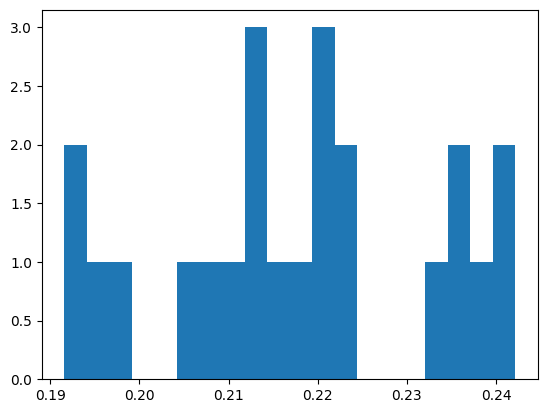

In [110]:
# Filter rows where 'last_cmd' is 'MOVE:2000'
move_distances = aligned_df[aligned_df['last_cmd'] == 'MOVE:2000']['distance_traveled']

plt.hist(move_distances[1:], bins = 20)


In [111]:
encoder_readings_per_cm = 2000/(move_distances.mean() * 100)
encoder_readings_per_cm

np.float64(95.88397477639684)

In [113]:
aligned_df.head()

,position_id,timestamp,vive_data,last_cmd,yaw,pitch,roll,x,y,z,distance_traveled
0,0,1.732839e+09,[ 0.26309819 -1.09524618 -1.30876942 17...,MOVE:2000,177.661983,-128.476225,-91.113422,0.000000,0.000000,0.000000,0.000000
1,0,1.732839e+09,[ 0.42968679 -1.09511243 -1.45375959 17...,MOVE:2000,177.427305,-127.922757,-92.233005,0.164759,0.147035,-0.003036,0.220848
2,0,1.732839e+09,[ 0.59399218 -1.09135685 -1.590056 17...,MOVE:2000,176.566521,-126.857531,-92.934577,0.327388,0.285377,-0.002357,0.213511
3,0,1.732839e+09,[ 0.59128207 -1.08919122 -1.59710649 179.03...,TURN:-1250,179.035732,141.384149,-89.217984,0.324617,0.292410,-0.000211,0.007858
4,0,1.732839e+09,[ 0.45758293 -1.088809 -1.79074297 -17...,MOVE:2000,-179.878824,142.912673,-89.893554,0.188531,0.484376,0.000373,0.235310


In [119]:
import numpy as np

def calculate_turn_angles(df):
    """
    Calculate the angle formed by vectors originating at the current row
    (for rows with 'TURN:-1250' in the 'last_cmd' column) and spanning to the
    x-y locations 2 rows back and 1 row forward.
    """
    # Ensure the DataFrame is sorted by position or time
    df = df.reset_index(drop=True)

    # Initialize a column for the calculated angles
    df['turn_angle'] = np.nan

    for i in range(2, len(df) - 1):
        if df.loc[i, 'last_cmd'] == 'TURN:-1250':
            # Coordinates for the current row
            x_curr, y_curr = df.loc[i, ['x', 'y']]

            # Coordinates 2 rows back
            x_back, y_back = df.loc[i - 2, ['x', 'y']]

            # Coordinates 1 row forward
            x_forward, y_forward = df.loc[i + 1, ['x', 'y']]

            # Vectors originating from the current row
            vector_back = np.array([x_back - x_curr, y_back - y_curr])
            vector_forward = np.array([x_forward - x_curr, y_forward - y_curr])

            # Normalize the vectors
            norm_back = np.linalg.norm(vector_back)
            norm_forward = np.linalg.norm(vector_forward)

            if norm_back > 0 and norm_forward > 0:
                vector_back = vector_back / norm_back
                vector_forward = vector_forward / norm_forward

                # Calculate the angle using the dot product
                dot_product = np.clip(np.dot(vector_back, vector_forward), -1.0, 1.0)
                angle = np.arccos(dot_product)  # Angle in radians

                # Convert to degrees and store in the DataFrame
                df.loc[i, 'turn_angle'] = np.degrees(angle)

    return df

# Apply the function to the DataFrame
aligned_df = calculate_turn_angles(aligned_df)

# Display the rows with calculated turn angles
aligned_df[['turn_angle']].dropna().mean()


turn_angle    87.60582
dtype: float64

In [117]:
aligned_df

,position_id,timestamp,vive_data,last_cmd,yaw,pitch,roll,x,y,z,distance_traveled,turn_angle
0,0,1.732839e+09,[ 0.26309819 -1.09524618 -1.30876942 17...,MOVE:2000,177.661983,-128.476225,-91.113422,0.000000,0.000000,0.000000,0.000000,NaN
1,0,1.732839e+09,[ 0.42968679 -1.09511243 -1.45375959 17...,MOVE:2000,177.427305,-127.922757,-92.233005,0.164759,0.147035,-0.003036,0.220848,NaN
2,0,1.732839e+09,[ 0.59399218 -1.09135685 -1.590056 17...,MOVE:2000,176.566521,-126.857531,-92.934577,0.327388,0.285377,-0.002357,0.213511,NaN
3,0,1.732839e+09,[ 0.59128207 -1.08919122 -1.59710649 179.03...,TURN:-1250,179.035732,141.384149,-89.217984,0.324617,0.292410,-0.000211,0.007858,96.950358
4,0,1.732839e+09,[ 0.45758293 -1.088809 -1.79074297 -17...,MOVE:2000,-179.878824,142.912673,-89.893554,0.188531,0.484376,0.000373,0.235310,NaN
5,0,1.732839e+09,[ 0.32435291 -1.09016693 -1.9914453 179.28...,MOVE:2000,179.286779,143.088089,-88.821444,0.052805,0.683400,-0.000841,0.240901,NaN
6,0,1.732839e+09,[ 0.19117164 -1.08922504 -2.18747175 -35.96...,MOVE:2000,-35.963926,143.346367,-89.090477,-0.082785,0.877766,0.000279,0.236991,NaN
7,0,1.732839e+09,[ 0.18403979 -1.08802842 -2.19597201 3.038612...,TURN:-1250,3.038613,50.720592,89.008244,-0.090007,0.886187,0.001500,0.011160,95.027640
8,0,1.732839e+09,[-9.43305641e-03 -1.09094622e+00 -2.08688319e+...,MOVE:2000,3.314060,52.285163,88.919711,-0.282127,0.774696,0.001816,0.222128,NaN
9,0,1.732839e+09,[-0.20255891 -1.09419116 -1.98186884 2.791583...,MOVE:2000,2.791583,52.162450,88.979215,-0.473956,0.667281,0.001770,0.219855,NaN
